In [1]:
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [2]:
dtype = torch.float64
device = torch.device("cpu")

# Example 1. The sum operation

### 1.1. Context Definition and Time Resolved Spectra

Here we introduce new object in MarS library - context. Context allows to describe relaxation mechanisms and initial populations

In [198]:
# Let's start from the sample creation
g_tensor = spin_model.Interaction([2.002, 2.003, 2.01], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([140e6, 40e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)]
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    device=device,
    mesh=(20, 20),
    dtype=dtype
)

In [207]:
1 / free_probs

tensor([[   inf, 0.0200,    inf],
        [0.0200,    inf, 0.0200],
        [   inf, 0.0200,    inf]], dtype=torch.float64)

In [199]:
init_populations = [0.502, 0.502, 0.500] # Let's make them almoust equel
init_populations  = [pop / sum(init_populations) for pop in init_populations]

out_probs = torch.tensor([5.0, 5.0, 5.0], device=device, dtype=dtype) * 5 # 40 ms is some depopulation time


free_probs = torch.tensor([[0.0, 1.0, 0.0],
                           [1.0, 0.0, 1.0],
                           [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 50 # 20 ms 


# No driven transitions in this example
driven_probs = None # Do not consider it here.

context_1 = population.Context(
    sample=triplet, basis="xyz", init_populations=init_populations, out_probs=out_probs, device=device, dtype=dtype, enforce_secularity=False)
context_2 = population.Context(
    sample=triplet, basis="eigen", init_populations=None, free_probs=free_probs, device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4]) 
context = context_1 + context_2

In [200]:
populator_prop = population.PropagatorDensityPopulator(
    omega_intensity=100, # Default walue of oscillating field intensity in Hz / 2pi
    angle_average_steps = 4,
    context=context,
    measurement_time=None, # By default MarS measures intensity in one oscillating period. Let's set this time as 10 µs. 
    init_temperature=300.0,
    n_steps=120, # For some cases this value can be ctucial. It significanlty increase the computation time. However if it is low, then the results will be broken. Usually 100-200 is more then enough
)

In [201]:
tr_spectra_creator = spectra_manager.DensityTimeSpectra(  # The most parameters are the same
    freq=9.8e9,    # Frequency in Hz 
    populator = "rwa",
    sample=triplet,
    harmonic=0, # absorbtion
    context=context,
    temperature=300.0,
    #hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 1800
time = torch.linspace(0.0, 100 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms

# Compute 2D spectra
spectrum_pop  = tr_spectra_creator(triplet, fields, time)
spectrum_pop = spectrum_pop / torch.max(torch.abs(spectrum_pop))

Text(0.5, 1.0, 'RWA Solution (Short Timescale)')

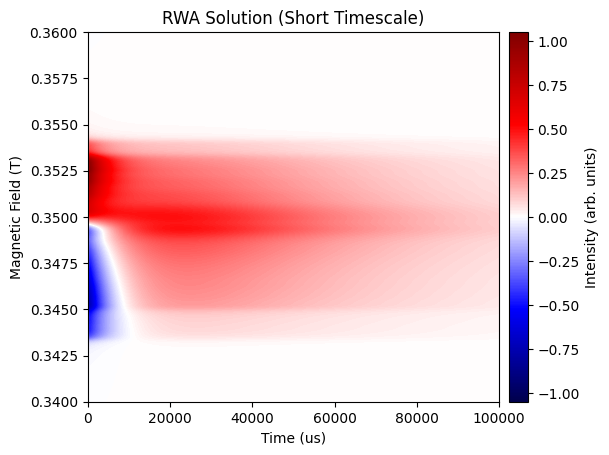

In [202]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us"
)
plt.title("RWA Solution (Short Timescale)")

Text(0.5, 1.0, 'RWA Solution (Short Timescale)')

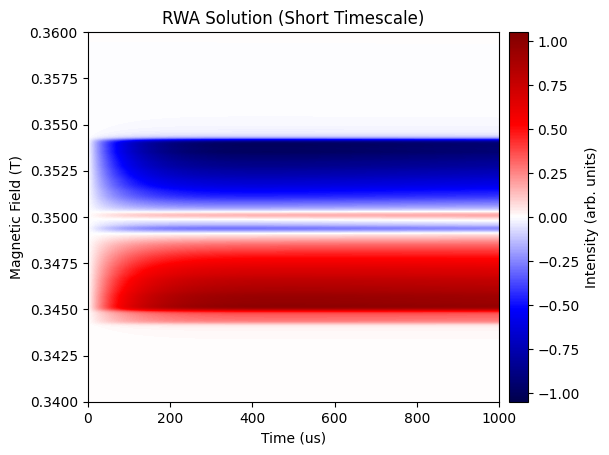

In [8]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us",
)
plt.title("RWA Solution (Short Timescale)")

### 1.2 The spectra evaluation in different methods

In [203]:
freq = 9.8e9
sample = triplet
harmonic = 0
temperature = 300.0
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)

populator_prop = population.PropagatorDensityPopulator(
    omega_intensity=100, # Default walue of oscillating field intensity in Hz / 2pi
    angle_average_steps = 8,
    context=context,
    measurement_time=None, # By default MarS measures intensity in one oscillating period. Let's set this time as 10 µs. 
    init_temperature=300.0,
    n_steps=200, # For some cases this value can be ctucial. It significanlty increase the computation time. However if it is low, then the results will be broken. Usually 100-200 is more then enough
)

creators = [
    {
        "name": "Coupled",
        "instance": spectra_manager.CoupledTimeSpectra(
            freq=freq,
            sample=sample,
            harmonic=harmonic,
            context=context,
            temperature=temperature,
            hamiltonian_mode="direct",
            device=device,
            dtype=dtype
        )
    },
    {
        "name": "Density (RWA)",
        "instance": spectra_manager.DensityTimeSpectra(
            freq=freq,
            populator="rwa",
            sample=sample,
            harmonic=harmonic,
            context=context,
            temperature=temperature,
            device=device,
            dtype=dtype
        )
    },
    {
        "name": "Density (Propagator)",
        "instance": spectra_manager.DensityTimeSpectra(
            freq=freq,
            populator=populator_prop,
            sample=sample,
            harmonic=harmonic,
            context=context,
            temperature=temperature,
            hamiltonian_mode="direct",
            device=device,
            dtype=dtype
        )
    }
]

tot_points = 1000
time_short = torch.linspace(0.0, 100e-6, tot_points, dtype=dtype, device=device)   # 100 us
time_long = torch.linspace(0.0, 100e-3, tot_points, dtype=dtype, device=device)    # 100 ms


results = []

print("Running simulations...")

for c_idx, creator_data in enumerate(creators):
    creator = creator_data["instance"]
    name = creator_data["name"]
    
    print(f"Simulating {name}...")
    
    # Compute Short Time
    spec_short = creator(sample, fields, time_short)
    
    # Compute Long Time
    spec_long = creator(sample, fields, time_long)
    
    results.append({
        "name": name,
        "short": {"time": time_short, "spectrum": spec_short},
        "long": {"time": time_long, "spectrum": spec_long}
    })

# ==========================================
# 3. NORMALIZATION
# ==========================================

target_norm_time = 50e-3  # 10 ms

print("Normalizing spectra...")

for res in results:
    t_long = res["long"]["time"]
    spec_long = res["long"]["spectrum"]
    
    idx_norm = torch.argmin(torch.abs(t_long - target_norm_time)).item()
    
    max_val = torch.max(torch.abs(spec_long[:, idx_norm]))
    
    if max_val < 1e-12:
        max_val = 1.0
        
    res["short"]["spectrum"] = res["short"]["spectrum"] / max_val
    res["long"]["spectrum"] = res["long"]["spectrum"] / max_val
    
    print(f"  {res['name']}: Normalized by factor {max_val:.4e} at t=10ms")

Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
  Coupled: Normalized by factor 5.9170e-04 at t=10ms
  Density (RWA): Normalized by factor 1.5760e+00 at t=10ms
  Density (Propagator): Normalized by factor 1.5948e+01 at t=10ms


### 1.3. Plot them in the shared heat map plot

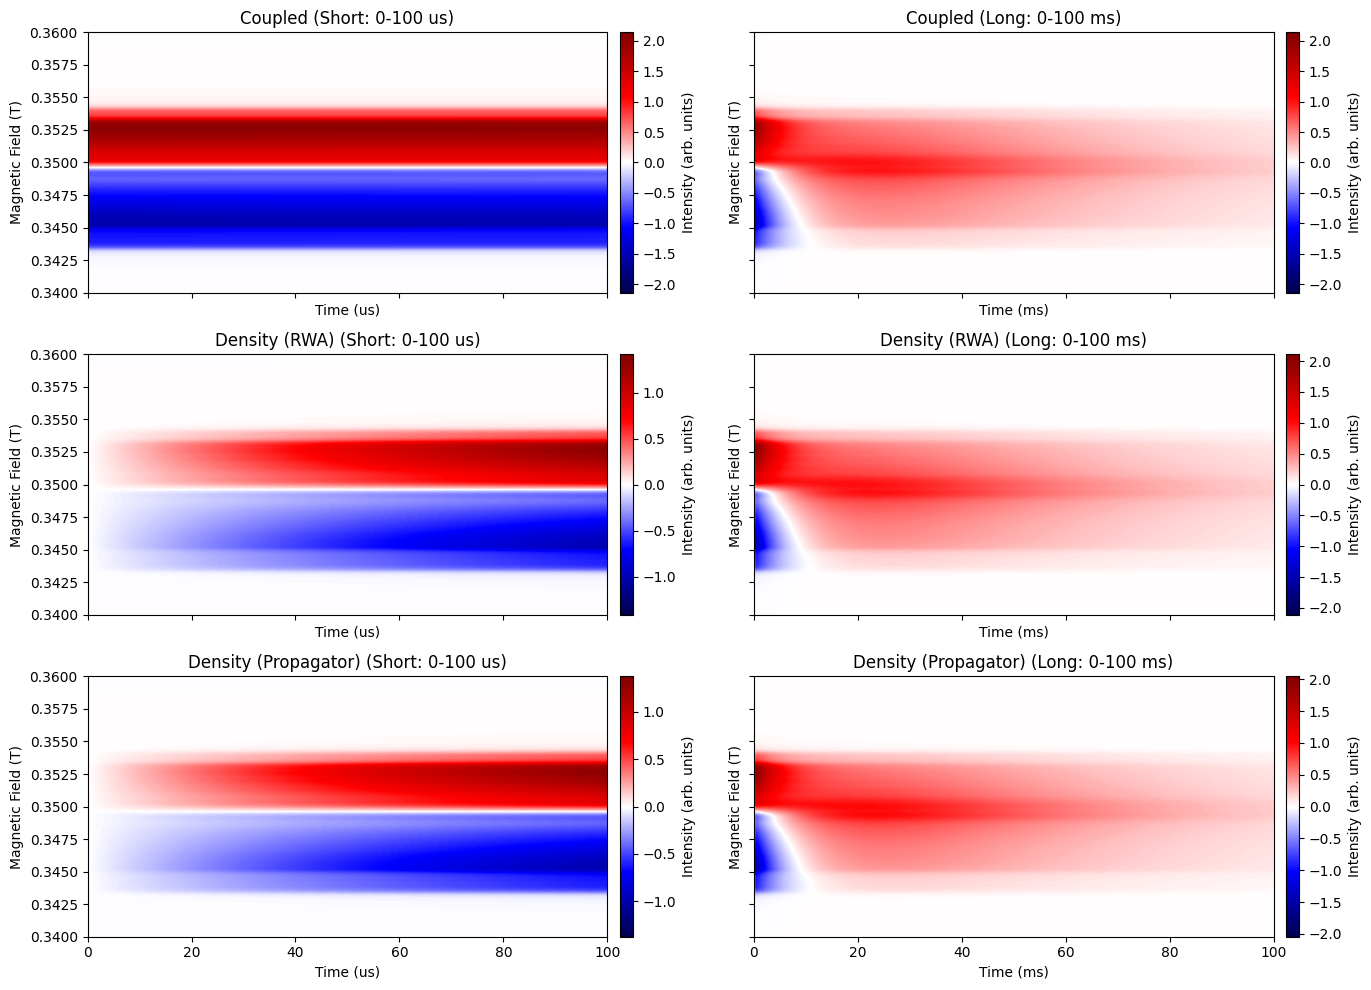

In [204]:
fig1, axes = plt.subplots(3, 2, figsize=(14, 10), sharex='col', sharey='row')

for i, res in enumerate(results):
    ax_short = axes[i, 0]
    plt.sca(ax_short) 
    
    visualization.plot_2d_timeresolved(
        fields,
        res["short"]["time"],
        res["short"]["spectrum"],
        time_unit="us"
    )
    
    ax_short.set_title(f"{res['name']} (Short: 0-100 us)")
    ax_long = axes[i, 1]
    plt.sca(ax_long)  # Set current axis for visualization function
    
    visualization.plot_2d_timeresolved(
        fields,
        res["long"]["time"],
        res["long"]["spectrum"],
        time_unit="ms"
    )
    ax_long.set_title(f"{res['name']} (Long: 0-100 ms)")

plt.tight_layout()
plt.show()

### 1.4. Plot field dependans plots

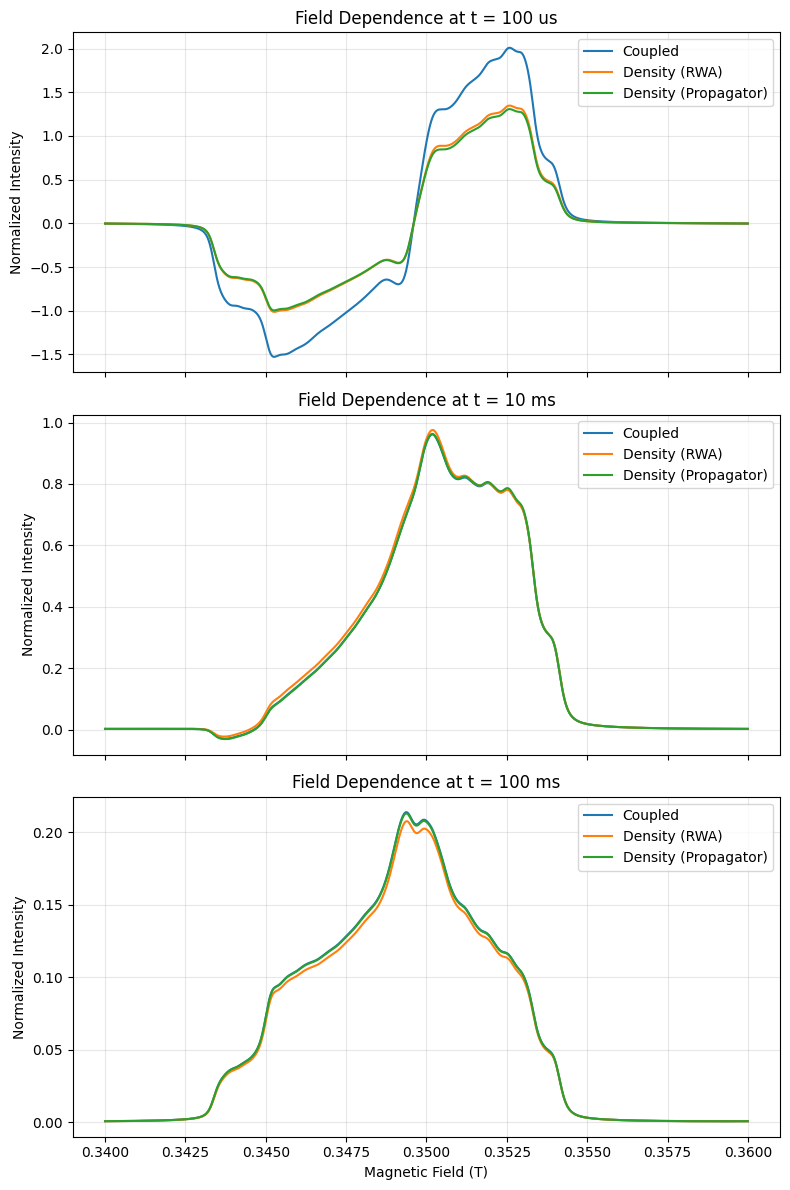

In [205]:
slice_times = [100e-6, 10e-3, 100e-3]
slice_labels = ["100 us", "10 ms", "100 ms"]

fig2, axes2 = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

fields_cpu = fields.cpu().numpy()

for j, (t_target, t_label) in enumerate(zip(slice_times, slice_labels)):
    ax = axes2[j]
    ax.set_title(f"Field Dependence at t = {t_label}")
    ax.set_ylabel("Normalized Intensity")
    if j == 2:
        ax.set_xlabel("Magnetic Field (T)")
    
    for i, res in enumerate(results):
        if t_target <= 100e-6:
            t_arr = res["short"]["time"]
            spec_arr = res["short"]["spectrum"]
            source = "short"
        else:
            t_arr = res["long"]["time"]
            spec_arr = res["long"]["spectrum"]
            source = "long"
        
        idx = torch.argmin(torch.abs(t_arr - t_target)).item()
        
        slice_data = spec_arr[idx, :].cpu().numpy()
        
        ax.plot(fields_cpu, slice_data, label=res["name"])
    
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Example 2. The concatination operation

### 2.1 Define the samples

In [7]:
# Let's start from the sample creation
g_tensor = spin_model.Interaction([2.002, 2.003, 2.01], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([140e6, 40e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)]
)

triplet_1 = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    device=device,
    mesh=(30, 30),
    dtype=dtype
)

# Let's start from the sample creation
g_tensor_2 = spin_model.Interaction([2.003, 2.004, 2.07], dtype=dtype, device=device)
zfs_interaction_2 = spin_model.DEInteraction([100e6, 20e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)],
    energy_shift = 100e9
)

triplet_2 = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    device=device,
    mesh=(30, 30),
    dtype=dtype
)

complex_sample = mars.concat((triplet_1, triplet_2))  # Create complex spin system of 6 levels

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:258: UserWarning: You are creating a block-diagonal (non-interacting) composite spin system via direct sum. This does NOT represent a true multi-particle quantum system (which would require a tensor-product space). Only use this if you are modeling effectively isolated subsystems (e.g., for polarized or time-resolved EPR). For physical spin clusters (diradicals, etc.), build a single SpinSystem with explicit couplings instead.
  concatenated_spin_system = concat_spin_systems(spin_systems)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:2065: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  width = torch.tensor(width, device=device, dtype=dtype)


### 2.2 Define the relaxation 

In [74]:
#............Triplet 1 BLOCK.........................
init_populations_1 = [0.502, 0.502, 0.500]
out_probs_1 = torch.tensor([0.0, 0.0, 0.0], device=device, dtype=dtype) * 0.0
# Level 0 ↔ Level 1 and Level 1 ↔ Level 2
free_probs_1 = torch.tensor([[0.0, 1.0, 0.0],
                           [1.0, 0.0, 1.0],
                           [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 50
driven_probs_1 = None # Do not consider it here.


#............Triple_2 Block.........................
init_populations_2 = [0.0, 0.0, 0.0]  # let's set zero initial population
out_probs_2 = torch.tensor([1.0, 2.0, 5.0], device=device, dtype=dtype) * 25

# Level 0 ↔ Level 1 and Level 1 ↔ Level 2
free_probs_2 = torch.tensor([[0.0, 1.0, 0.0],
                           [1.0, 0.0, 1.0],
                           [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 10
driven_probs_2 = None # Do not consider it here.


#............Chemical Kynetic MATRIX.........................

# Define coupling matrix: transitions from reservoir states (-1, 0, +1) 
# to corresponding probe states (-1, 0, +1) with equal rate.
couple_matrix = torch.tensor([[1.0, 0.0, 0.0],
                            [0.0, 1.0, 0.0],
                            [0.0, 0.0, 1.0]], device=device, dtype=dtype) * 50.0

dim = 6  # the full dimension of the system
couple_matrix_expanded = torch.zeros((dim, dim), device=device, dtype=dtype)
triplet_1_idx = torch.tensor([3, 4, 5], device=device)  # reservoir inedexes in expended system
triplet_2_idx = torch.tensor([0, 1, 2], device=device)  # probe inedexes in expended system
couple_matrix_expanded.index_put_((triplet_1_idx.unsqueeze(1), triplet_2_idx.unsqueeze(0)), couple_matrix)


tensor([[ 0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.],
        [50.,  0.,  0.,  0.,  0.,  0.],
        [ 0., 50.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 50.,  0.,  0.,  0.]], dtype=torch.float64)

In [75]:
context_1 = population.Context(basis="xyz", sample=triplet_1, init_populations=init_populations_1, out_probs=out_probs_1, device=device, dtype=dtype) +\
                population.Context(basis="eigen", sample=triplet_1, free_probs=free_probs_1, device=device, dtype=dtype)


context_2 = population.Context(basis="xyz", sample=triplet_2, init_populations=init_populations_2, out_probs=out_probs_2, device=device, dtype=dtype) +\
                    population.Context(basis="eigen", sample=triplet_2, free_probs=free_probs_2, device=device, dtype=dtype)

kynetic_context = population.Context(basis="eigen", sample=complex_sample, driven_probs=couple_matrix_expanded)
# Create kynetic context

full_relaxation_context = mars.concat((context_1, context_2)) + kynetic_context  #

In [76]:
temperature = 300.0

tr_spectra_creator = spectra_manager.CoupledTimeSpectra(
    output_mode="transitions",  # Now we need to get separate spectra of each transition levels becasue we need only probe (low-lying in our definition)
    freq=9.8e9,
    sample=complex_sample,
    harmonic=0,
    context=full_relaxation_context,
    temperature=temperature,
    device=device,
    dtype=dtype
)

fields = torch.linspace(0.335, 0.365, 1000, dtype=dtype, device=device)  # Field in Tesla
tot_points = 800
time = torch.linspace(0.0, 0.1, tot_points, dtype=dtype, device=device)  #

lvl_down, lvl_up, spectrum = tr_spectra_creator(complex_sample, fields, time)

In [77]:
spectrum_1 = (spectrum[0] + spectrum[2]) / 2
spectrum_2 = (spectrum[1] + spectrum[3]) / 2

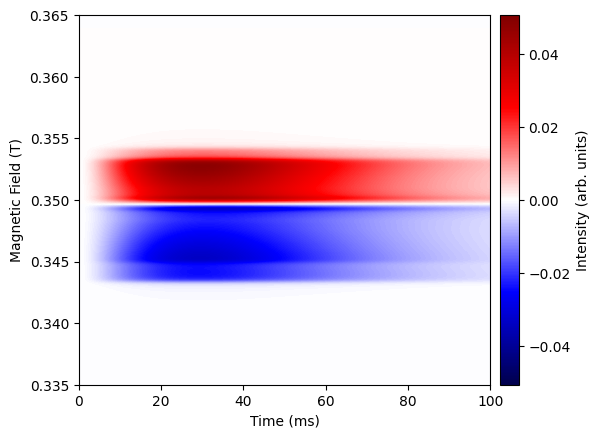

In [78]:
visualization.plot_2d_timeresolved(
        fields,
        time,
        spectrum_2,
        time_unit="ms"
    )

In [ ]:
spectrum_np = spectrum.cpu().numpy()
spectrum_np = spectrum_np / np.max(np.abs(spectrum_np))

time_points = [0.0 * 1e-3 , 5.0 * 1e-3 , 15.0 * 1e-3 ] # times (s) to plot field-dependant spectra at the given time
field_points = [0.345, 0.35, 0.355]  # fields (T) to plot kynetics at the given times

# --- Create mosaic layout: heat map + kinetics on left, field dependence on right ---
fig, axes = plt.subplot_mosaic([['one', 'three'],
                                ['two', 'three']], figsize=(14, 10))

# 1.
plt.sca(axes["one"])
visualization.plot_2d_timeresolved(fields, time, spectrum_np, time_unit="ms")
plt.xlabel("Time (ms)")
plt.ylabel("Magnetic Field (T)")
plt.title("Time-Resolved Spectrum")

# 2. Kinetic traces (bottom-left)
plt.sca(axes["two"])
for b_val in field_points:
    visualization.plot_kinetic(b_val, fields, time, spectrum_np, time_unit="ms")
plt.xlabel("Time (ms)")
plt.ylabel("Intensity (arb. units)")
plt.title("Kinetics at Selected Fields")
plt.legend([f"B = {b:.3f} T" for b in field_points])

# 3. Field-dependent spectra (right)
plt.sca(axes["three"])
for t_val in time_points:
    visualization.plot_field_dependence(t_val, fields, time, spectrum_np)
plt.xlabel("Magnetic Field (T)")
plt.ylabel("Intensity (arb. units)")
plt.title("Field Dependence")
plt.legend([f"t = {t*1e3:.1f} ms" for t in time_points])

plt.show()